In [1]:
import tempfile
import pickle
import sys
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from scipy.special import logit, softmax
import os
import scipy.stats as stats
from os.path import join
import pickle as pkl
import bambi as bmb
import arviz as az
import numpy as np

import concurrent.futures
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import sys

from sklearn.metrics import balanced_accuracy_score


import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.stats import zscore




### interaction between action kernel prior strength, engagement and pupil-size

In [2]:
import pickle as pkl

In [3]:
complete_df = pd.read_parquet('../data/generated/pupilometry/complete_pupil_df.pqt')

In [4]:
# zscore the pupil and motivation_scalar

In [5]:
complete_df.columns

Index(['goCueTrigger_times', 'intervals_bpod_0', 'intervals_bpod_1',
       'quiescencePeriod', 'stimOff_times', 'firstMovement_times',
       'goCue_times', 'probabilityLeft', 'response_times', 'feedbackType',
       'rewardVolume', 'contrastRight', 'choice', 'feedback_times',
       'stimOn_times', 'contrastLeft', 'intervals_0', 'intervals_1',
       'p_state1', 'p_state2', 'signed_contrast', 'rewarded', 'akernel_prior',
       'pe_right', 'motivation_scalar', 'pupil_mean', 'pupil_std',
       'first_movement_time', 'response', 'eid', 'stimOnTrigger_times'],
      dtype='object')

In [6]:
def clean_df_zscored(df):    
    df = df.copy()
    df['pupil_mean_z'] = df.groupby('eid')['pupil_mean'].transform(lambda x: (x - x.mean()) / x.std())
    df['motivation_scaled'] = df.groupby('eid')['motivation_scalar'].transform(lambda x: (x-x.mean())/x.std())

    condition_left_congruent = (df['probabilityLeft'] == 0.8) & (df['signed_contrast'] >= 0)
    condition_right_congruent = (df['probabilityLeft'] == 0.2) & (df['signed_contrast'] <= 0)
    df['is_congruent'] = (condition_left_congruent | condition_right_congruent).astype(int)
    df['feedback_binary'] = (df['feedbackType'] == 1.0).astype(int)
    df['abs_contrast'] = np.abs(df['signed_contrast'])
    return df

In [7]:
transformed_df = clean_df_zscored(complete_df)

In [9]:
# inc_trials['abs_contrast'].unique()
transformed_df['confidence'] = np.abs(transformed_df['akernel_prior']-0.5)

In [26]:
trial_indices = transformed_df.groupby('eid').cumcount()

In [32]:
total_trials = transformed_df.groupby('eid')['eid'].transform('size')

In [34]:
filtered_trials = transformed_df[trial_indices < (total_trials * 0.95)].copy()

In [35]:
formula_global = "feedback_binary ~ is_congruent * motivation_scaled * confidence + C(abs_contrast) + (1|eid)"

model_phase1_global = bmb.Model(
    formula_global, 
    data=filtered_trials, # Now safe to use the full dataset
    family="bernoulli",
    dropna=True
)
idata_phase1 = model_phase1_global.fit(draws=2000, chains=4, target_accept=0.9)

Modeling the probability that feedback_binary==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, is_congruent, motivation_scaled, is_congruent:motivation_scaled, confidence, is_congruent:confidence, motivation_scaled:confidence, is_congruent:motivation_scaled:confidence, C(abs_contrast), 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 235 seconds.


In [36]:
vars=["is_congruent","motivation_scaled","is_congruent:motivation_scaled","confidence","is_congruent:confidence","motivation_scaled:confidence","is_congruent:motivation_scaled:confidence"]

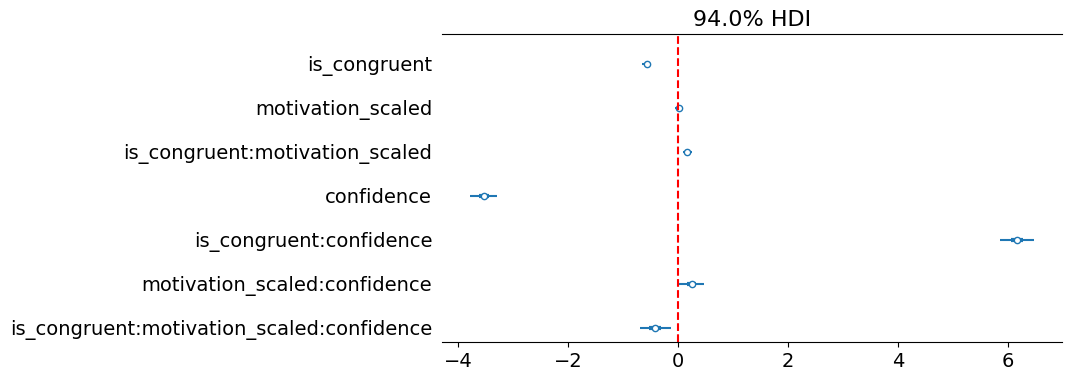

In [37]:
fig, ax = plt.subplots(figsize=(8,4))
az.plot_forest(idata_phase1, var_names=vars, combined=True, ax=ax)
ax.axvline(0,color='r',linestyle='--')

In [38]:
# just look at incongruent trials

inc_trials = filtered_trials[(filtered_trials['is_congruent']==False) &  (filtered_trials['abs_contrast'] > 0)].copy()
conc_trials = filtered_trials[(filtered_trials['is_congruent']==True) &  (filtered_trials['abs_contrast'] > 0)].copy()


In [39]:
model_phase1 = bmb.Model(
    "feedback_binary ~ motivation_scaled * confidence + C(abs_contrast) + (1|eid)", 
    data=inc_trials, 
    family="bernoulli",
    dropna=True
)
idata_phase1 = model_phase1.fit(draws=2000, chains=4, target_accept=0.9)


Modeling the probability that feedback_binary==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, motivation_scaled, confidence, motivation_scaled:confidence, C(abs_contrast), 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 49 seconds.


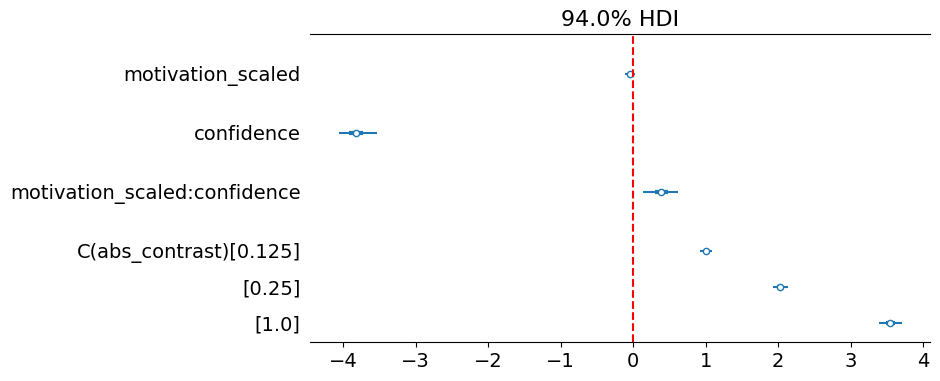

In [40]:
fig, ax = plt.subplots(figsize=(8,4))
az.plot_forest(idata_phase1, var_names=["motivation_scaled", "confidence", "motivation_scaled:confidence", "C(abs_contrast)"], combined=True, ax=ax)
ax.axvline(0,color='r',linestyle='--')


<Axes: xlabel='att_bin', ylabel='confidence_bin'>

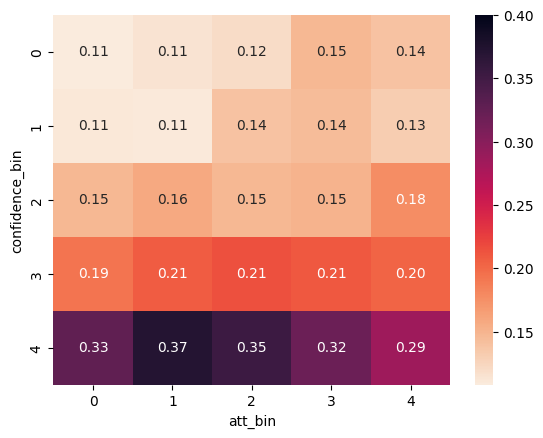

In [41]:
inc_trials['att_bin'] = pd.qcut(inc_trials['motivation_scaled'], q=5, labels=False, duplicates='drop')
inc_trials['confidence_bin'] = pd.qcut(inc_trials['confidence'], q=5, labels=False, duplicates='drop')
inc_trials['error'] = 1-inc_trials['feedback_binary']
heatmap_data = inc_trials.groupby(['confidence_bin', 'att_bin'])['error'].mean().unstack()
sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap='rocket_r', 
    fmt=".2f", 
    vmax=0.4
)


In [42]:
# what about congruence
model_phase2 = bmb.Model(
    "feedback_binary ~ motivation_scaled * confidence + C(abs_contrast) + (1|eid)", 
    data=conc_trials, 
    family="bernoulli",
    dropna=True
)
idata_phase2 = model_phase2.fit(draws=2000, chains=4, target_accept=0.9)


Modeling the probability that feedback_binary==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, motivation_scaled, confidence, motivation_scaled:confidence, C(abs_contrast), 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 91 seconds.


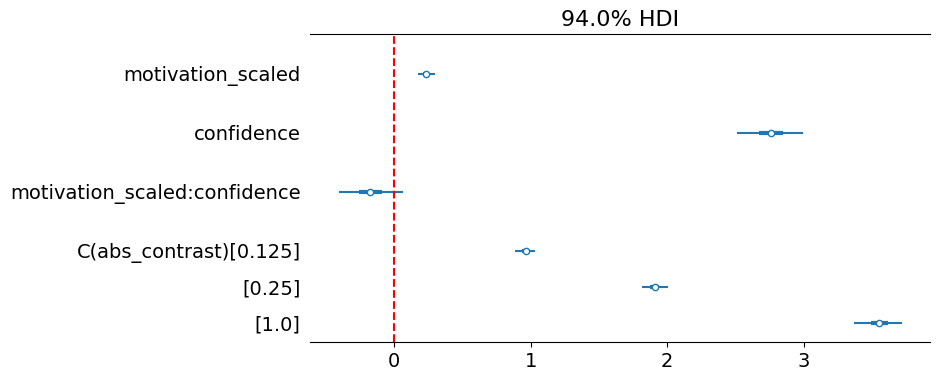

In [43]:
fig, ax = plt.subplots(figsize=(8,4))
az.plot_forest(idata_phase2, var_names=["motivation_scaled", "confidence", "motivation_scaled:confidence", "C(abs_contrast)"], combined=True, ax=ax)
ax.axvline(0,color='r',linestyle='--')


<Axes: xlabel='att_bin', ylabel='confidence_bin'>

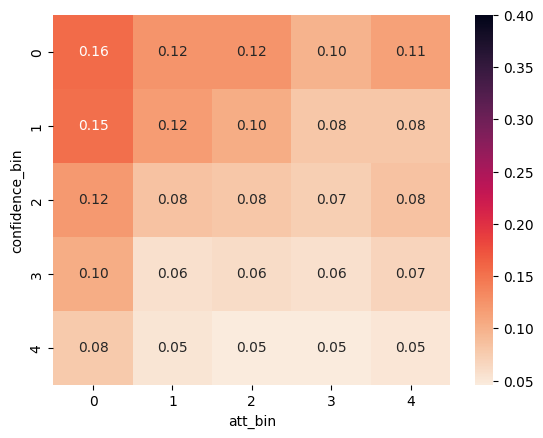

In [44]:
conc_trials['att_bin'] = pd.qcut(conc_trials['motivation_scaled'], q=5, labels=False, duplicates='drop')
conc_trials['confidence_bin'] = pd.qcut(conc_trials['confidence'], q=5, labels=False, duplicates='drop')
conc_trials['error'] = 1-conc_trials['feedback_binary']
heatmap_data = conc_trials.groupby(['confidence_bin', 'att_bin'])['error'].mean().unstack()
sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap='rocket_r', 
    fmt=".2f", 
    vmax=0.4
)


In [45]:
# okay, so we kind of see what we expected
# now to link pupil size to this


In [46]:
# link with pupil - how?

### Animal wise pupil fluctuations, and then group

In [35]:
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon
from tqdm import tqdm

In [ ]:
formula = "pupil_mean_z ~ motivation_scaled * confidence"
iterations = 1000

all_beta_records = []

for animal_id, subject_df in tqdm(transformed_df.groupby('eid')):
    if len(subject_df) < 20:
        continue
        
    true_model = smf.ols(formula, data=subject_df).fit()
    true_r2 = true_model.rsquared
    
    null_r2_values = np.zeros(iterations)
    shuffled_df = subject_df.copy()
    
    for i in range(iterations):
        shuffled_df['pupil_mean_z'] = np.random.permutation(shuffled_df['pupil_mean_z'].values) # type: ignore
        null_model = smf.ols(formula, data=shuffled_df).fit()
        null_r2_values[i] = null_model.rsquared
        
    null_threshold = np.percentile(null_r2_values, 95)

    betas = true_model.params.to_dict()
    betas['animal'] = animal_id
    if true_r2 > null_threshold:
        betas['valid'] = True 
    else:
        betas['valid']= False
    all_beta_records.append(betas)


100%|██████████| 202/202 [04:16<00:00,  1.27s/it]


In [ ]:
all_beta_records = pd.DataFrame(all_beta_records).copy()

In [78]:
all_beta_records.to_parquet('../data/generated/pupilometry/beta_weights_all.pqt')

In [81]:
valid_beta_records = all_beta_records[all_beta_records['valid']==True]

In [82]:
from statsmodels.stats.multitest import multipletests


In [92]:
def plot_results(beta_records):
    filtered_beta_df = pd.DataFrame(beta_records).set_index('animal').drop(columns=['valid']).copy()
    predictors = [
        'motivation_scaled', 
        'confidence', 
        'motivation_scaled:confidence'
    ]

    
    stats_list = []
    for predictor in predictors:

        coef_array = filtered_beta_df[predictor].dropna().values
        mean_beta = np.mean(coef_array) # type: ignore
        sem_beta = np.std(coef_array, ddof=1) / np.sqrt(len(coef_array)) # type: ignore
        
        stat, p_val = wilcoxon(coef_array)
        
        stats_list.append({
            'Predictor': predictor,
            'Mean_Beta': mean_beta,
            'SEM': sem_beta,
            'p_value_raw': p_val
        })

    group_stats_df = pd.DataFrame(stats_list)
    
    _, pvals_fdr, _, _ = multipletests(group_stats_df['p_value_raw'], alpha=0.05, method='fdr_bh')
    group_stats_df['p_value_fdr'] = pvals_fdr

    predictor_mapping = {
        'motivation_scaled': 'Motivation',
        'confidence': 'Confidence',
        'motivation_scaled:confidence': 'Motivation × Confidence'
    }
    group_stats_df['Clean_Label'] = group_stats_df['Predictor'].map(predictor_mapping)


    plot_df = group_stats_df.sort_values('Mean_Beta').reset_index(drop=True)


    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x='Mean_Beta', 
        y='Clean_Label', 
        data=plot_df, 
        color='silver', 
        edgecolor='black',
        errorbar=None 
    )

    plt.errorbar(
        x=plot_df['Mean_Beta'], 
        y=np.arange(len(plot_df)), 
        xerr=plot_df['SEM'], 
        fmt='none', 
        c='black', 
        capsize=3
    )

    for index, row in plot_df.iterrows():
        if row['p_value_fdr'] < 0.001:
            sig_marker = '***'
        elif row['p_value_fdr'] < 0.01:
            sig_marker = '**'
        elif row['p_value_fdr'] < 0.05:
            sig_marker = '*'
        else:
            sig_marker = 'ns'
        
        # Offset the text slightly beyond the error bar
        offset = np.sign(row['Mean_Beta']) * (row['SEM'] + 0.03)
        
        # Handle the visual placement depending on positive/negative beta
        plt.text(
            row['Mean_Beta'] + offset, 
            index, 
            sig_marker, 
            va='center',
            ha='left' if row['Mean_Beta'] >= 0 else 'right',
            fontsize=10
        )

    # Formatting the plot
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel('Mean Betas')
    plt.ylabel('Model Predictors')
    plt.title('Group-Level Fixed Effects')
    sns.despine()
    # plt.tight_layout()
    plt.show()

    return group_stats_df

In [93]:
# plot_results(valid_beta_records)

In [99]:
bambi_formula = "pupil_mean_z ~ motivation_scaled * confidence + (1 | eid)"

In [100]:
model = bmb.Model(formula, transformed_df, dropna=True)

Automatically removing 457/85976 rows from the dataset.


In [101]:
idata = model.fit(draws=2000, tune=1000, target_accept=0.95, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, motivation_scaled, confidence, motivation_scaled:confidence]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.


In [102]:
import arviz as az

Text(0.5, 1.0, 'Pupil estimates')

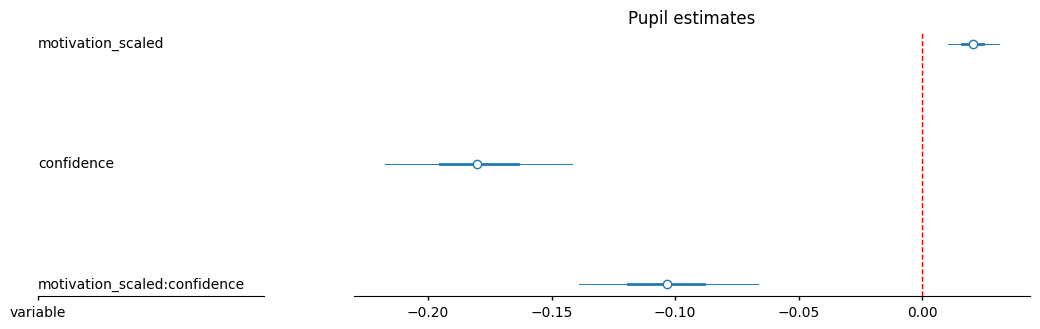

In [120]:
# fig, ax = plt.subplots(figsize=(8,4))
az.plot_forest(idata, combined=True, var_names=['motivation_scaled', 'confidence', 'motivation_scaled:confidence'],ci_kind='hdi')
ax.axvline(0,color='r',linestyle='--')
ax = plt.gca()
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Pupil estimates')

In [ ]:

model.predict(idata, kind="pps")


az.plot_ppc(idata, num_pp_samples=20)
plt.show()

/Users/dkundu/mamba/envs/custom-rnn/lib/python3.12/site-packages/bambi/models.py:972: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


In [135]:
summary_df = az.summary(
    idata, 
    var_names=['Intercept', 'motivation_scaled', 'confidence', 'motivation_scaled:confidence']
)
print("--- Model Convergence Summary ---")
print(summary_df[['mean', 'sd', 'r_hat', 'ess_bulk']])

--- Model Convergence Summary ---
                                 mean      sd r_hat  ess_bulk
Intercept                       0.048  0.0068  1.00      7527
motivation_scaled              0.0205  0.0065  1.00      4873
confidence                    -0.1803  0.0238  1.00      7330
motivation_scaled:confidence  -0.1032  0.0229  1.00      4887


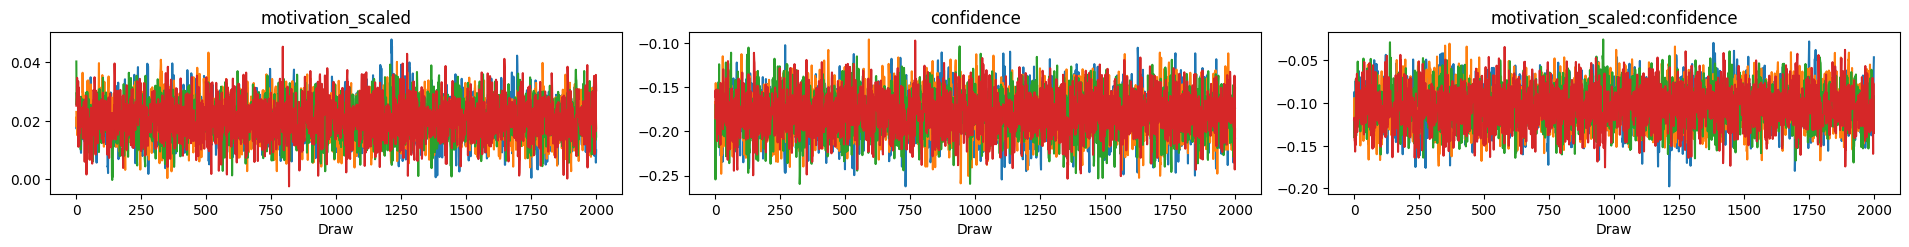

In [137]:
az.plot_trace(
    idata, 
    var_names=['motivation_scaled', 'confidence', 'motivation_scaled:confidence'],
)
plt.tight_layout()
plt.show()